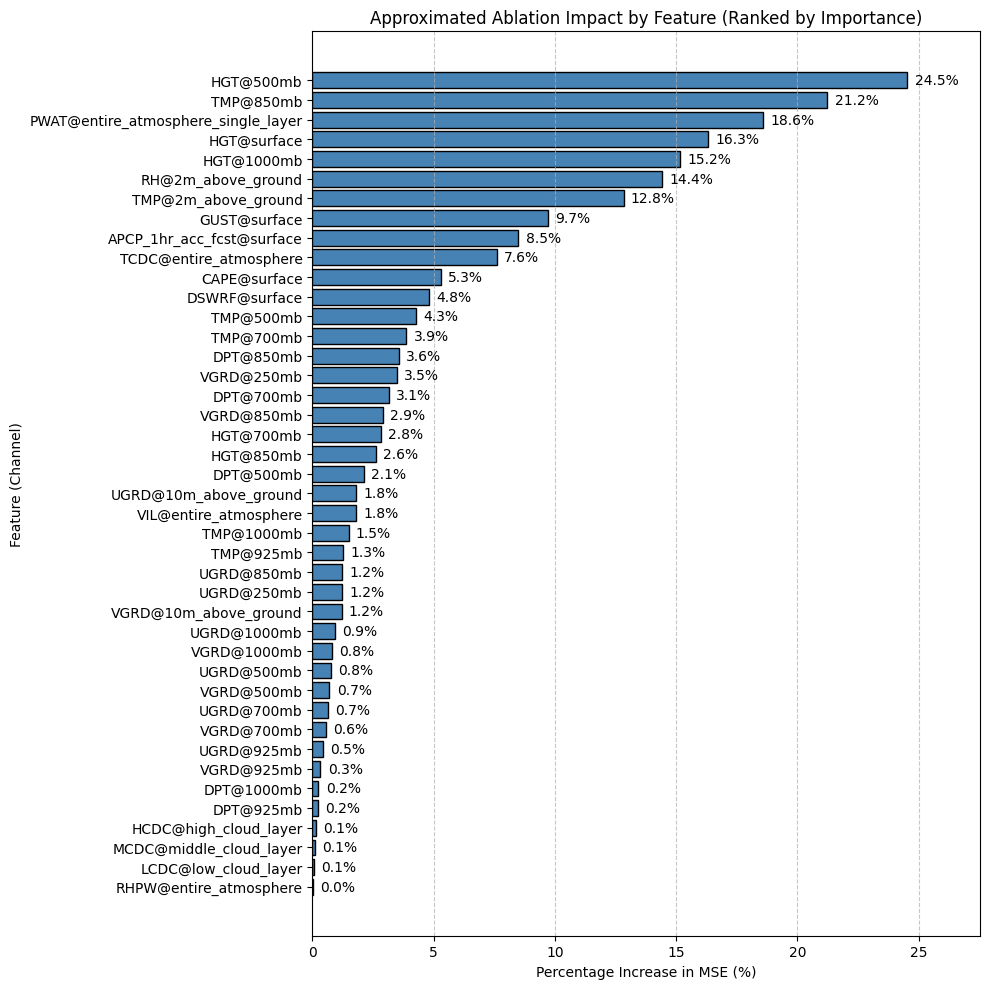

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# The approximated data string
csv_data = r"ablation_results/ablation_results.csv"

# Read the data into a pandas dataframe
df = pd.read_csv(csv_data)

# Sort the values from lowest to highest so the most important features appear at the top
df = df.sort_values(by='pct_increase', ascending=True)

# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 10))

# Plot horizontal bars
bars = ax.barh(df['channel'], df['pct_increase'], color='steelblue', edgecolor='black')

# Format the plot
ax.set_xlabel('Percentage Increase in MSE (%)')
ax.set_ylabel('Feature (Channel)')
ax.set_title('Approximated Ablation Impact by Feature (Ranked by Importance)')
ax.grid(axis='x', linestyle='--', alpha=0.7)

# Add exact value labels to the right of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.3, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center')

# Extend x-axis limits slightly to ensure labels aren't cut off
ax.set_xlim(0, max(df['pct_increase']) + 3)

# Adjust layout to prevent label clipping
plt.tight_layout()

# Save the figure
# plt.savefig('feature_importance.png')

The top 3 features are:
- HGT@500mb: tracks the storm system (500mb ~ 5-6km in the atmosphere)
- TMP@850: Measures temperature at around 1.5km into the atmosphere, so high enough to avoid surface noise (urban heat, terrain differences, time of day)
- PWAT@entire_atmosphere_single_layer: high moisture levels corelate with heavy rain potential


I am spliting the metrics into 5 broad categories: Temperature (TMP), Geopotential Height (HGT), Zonal Wind (UGRD), Meridional Wind (VGRD) and Dew Point (DPT)

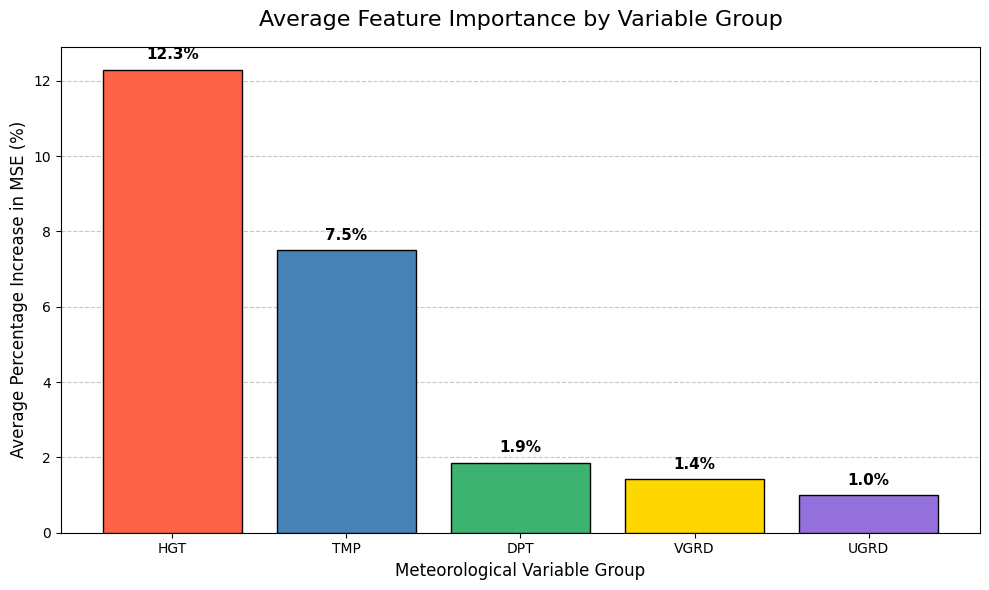

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import io

csv_data = r"ablation_results/ablation_results.csv"

# Read into DataFrame
df = pd.read_csv(csv_data)

# Extract the base variable group (everything before the '@')
df['group'] = df['channel'].apply(lambda x: x.split('@')[0])

# Filter strictly to the 5 targeted groups from the previous profile analysis
target_groups = ['TMP', 'HGT', 'UGRD', 'VGRD', 'DPT']
df_filtered = df[df['group'].isin(target_groups)]

# Group by the variable and calculate the average percentage increase
avg_df = df_filtered.groupby('group')['pct_increase'].mean().reset_index()

# Sort values for a cleaner visual flow (descending order)
avg_df = avg_df.sort_values(by='pct_increase', ascending=False)

# Initialize the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Assign 5 distinct colors for visual separation
colors = ['tomato', 'steelblue', 'mediumseagreen', 'gold', 'mediumpurple']

# Plot the bars
bars = ax.bar(avg_df['group'], avg_df['pct_increase'], color=colors, edgecolor='black', zorder=3)

# Formatting the plot
ax.set_title('Average Feature Importance by Variable Group', fontsize=16, pad=15)
ax.set_ylabel('Average Percentage Increase in MSE (%)', fontsize=12)
ax.set_xlabel('Meteorological Variable Group', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

# Add exact value labels sitting on top of the bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.2, f'{height:.1f}%', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Finish up and save
plt.tight_layout()
# plt.savefig('average_importance.png')

Geopotential height is the most important of the of the 5 metrics, wind metrics, VGRD and UGRD are least important.

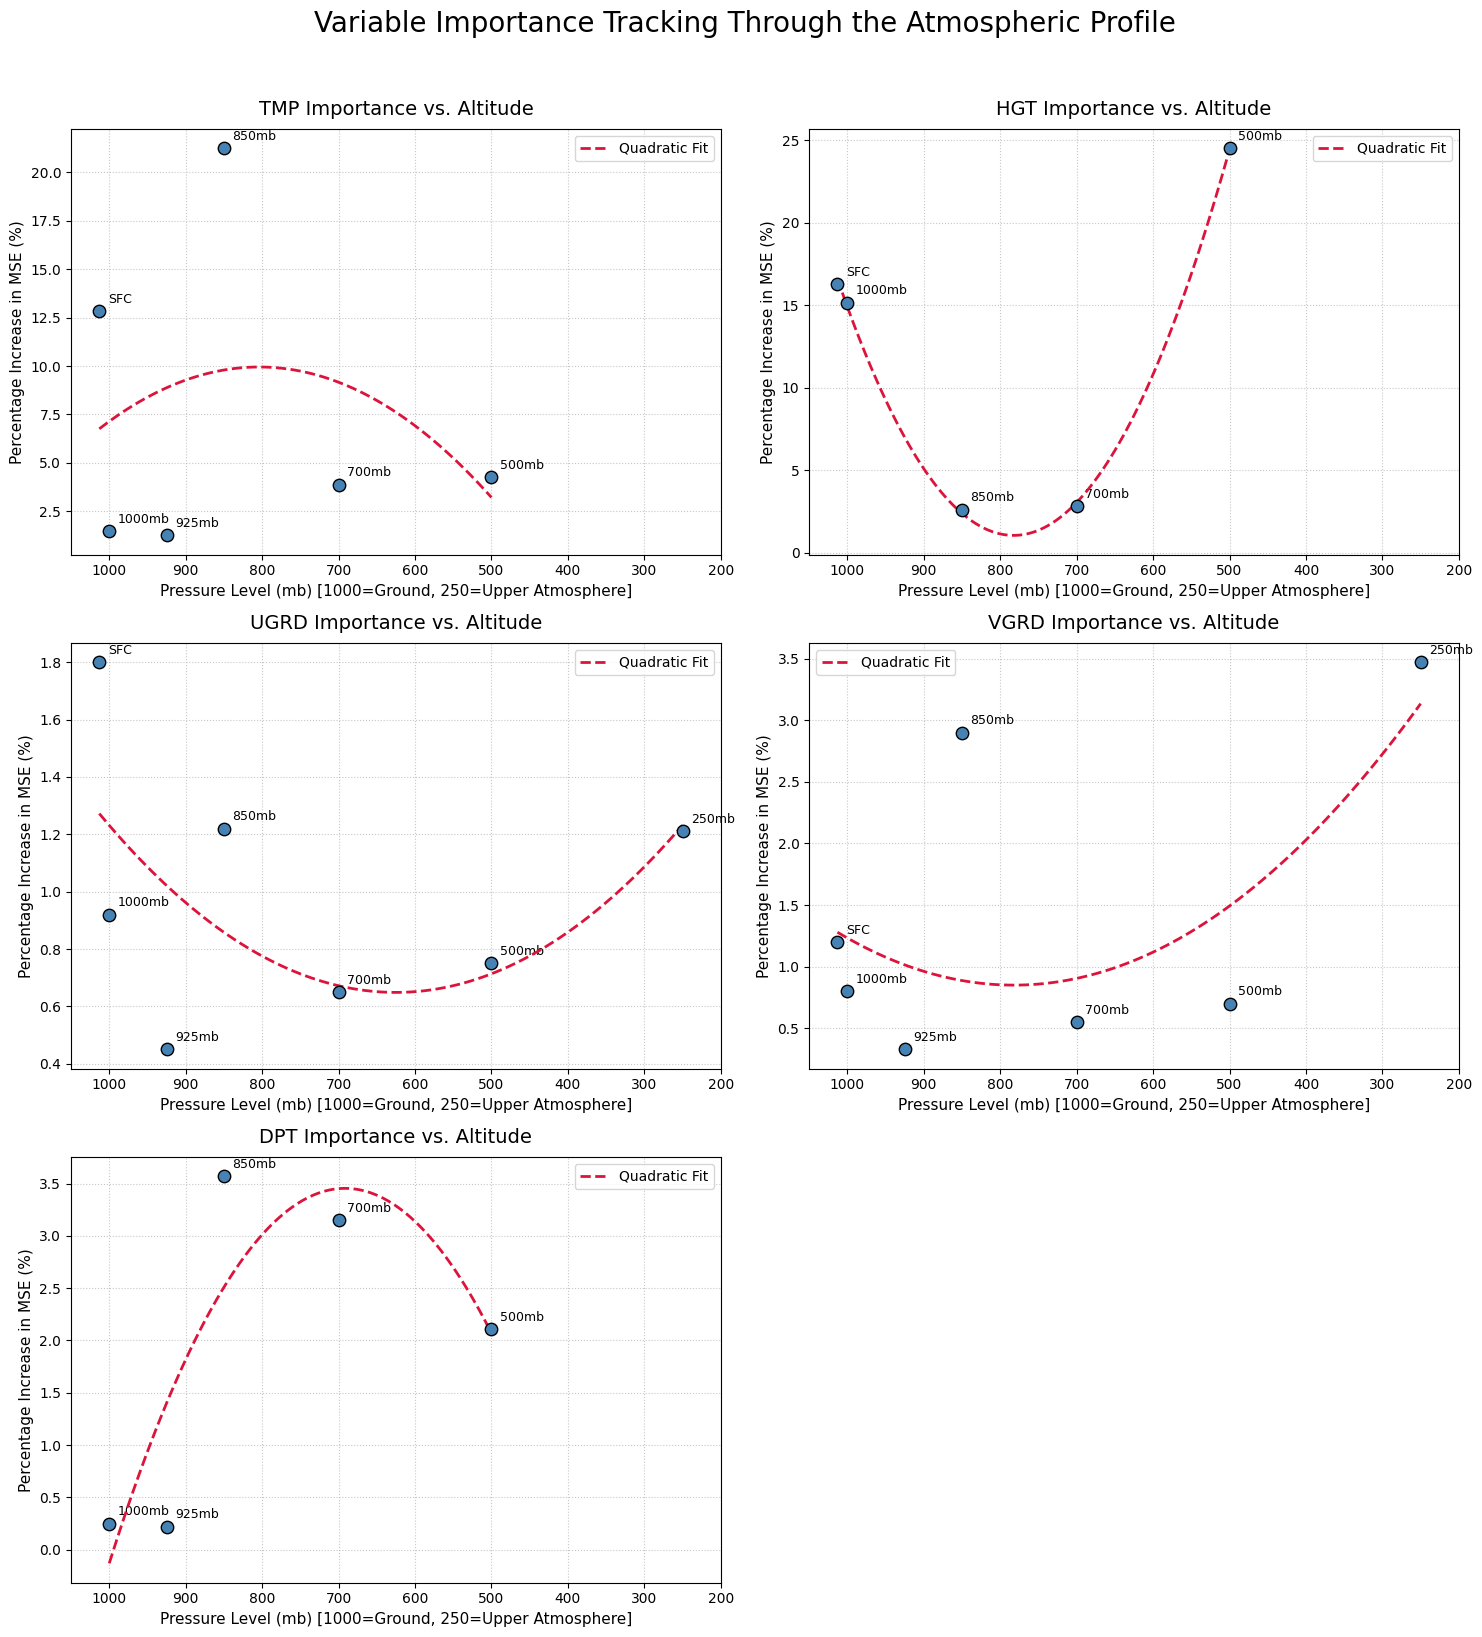

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import io

csv_data = r"ablation_results/ablation_results.csv"

df = pd.read_csv(csv_data)

# Function to extract the variable and convert the height level to a numeric pressure in millibars (mb)
def parse_data(row):
    chan = row['channel']
    var = chan.split('@')[0]
    
    # Standard Mean Sea Level Pressure is roughly 1013mb. 
    # We assign 1013 to surface/2m/10m to create a continuous numeric axis for height.
    if '1000mb' in chan: press = 1000
    elif '925mb' in chan: press = 925
    elif '850mb' in chan: press = 850
    elif '700mb' in chan: press = 700
    elif '500mb' in chan: press = 500
    elif '250mb' in chan: press = 250
    elif 'surface' in chan or '2m' in chan or '10m' in chan: press = 1013
    else: press = None
    return pd.Series([var, press])

# Apply parsing
df[['Variable', 'Pressure_mb']] = df.apply(parse_data, axis=1)
df = df.dropna(subset=['Pressure_mb'])

target_vars = ['TMP', 'HGT', 'UGRD', 'VGRD', 'DPT']

# Setup a 3x2 grid of subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 16))
axes = axes.flatten()

for i, var in enumerate(target_vars):
    ax = axes[i]
    subset = df[df['Variable'] == var].sort_values('Pressure_mb')
    
    x = subset['Pressure_mb'].values
    y = subset['pct_increase'].values
    
    # Create the scatter plot
    ax.scatter(x, y, color='steelblue', s=80, edgecolor='black', zorder=5)
    
    # Calculate and plot the quadratic line of best fit (Polynomial of degree 2)
    if len(x) >= 3:
        coefs = np.polyfit(x, y, 2)
        # Create a smooth line across the X axis range
        x_smooth = np.linspace(max(x), min(x), 100)
        y_smooth = np.polyval(coefs, x_smooth)
        ax.plot(x_smooth, y_smooth, color='crimson', linestyle='--', linewidth=2, label='Quadratic Fit', zorder=4)
    
    # Met plotting standard: Invert X axis so high pressure (ground) is on left, low pressure (high atmosphere) is on right.
    ax.set_xlim(1050, 200)
    
    ax.set_title(f'{var} Importance vs. Altitude', fontsize=14, pad=10)
    ax.set_xlabel('Pressure Level (mb) [1000=Ground, 250=Upper Atmosphere]', fontsize=11)
    ax.set_ylabel('Percentage Increase in MSE (%)', fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.7)
    
    if len(x) >= 3:
        ax.legend()
        
    # Add annotations to the points for clarity
    for j, txt in enumerate(subset['channel']):
        label = txt.split('@')[1].replace('_above_ground', '').replace('_layer', '')
        if label in ['surface', '2m', '10m']: label = 'SFC'
        ax.annotate(label, (x[j], y[j]), xytext=(6, 6), textcoords='offset points', fontsize=9)

# Remove the empty 6th subplot
fig.delaxes(axes[5])

plt.suptitle('Variable Importance Tracking Through the Atmospheric Profile', fontsize=20, y=1.02)
plt.tight_layout()
# plt.savefig('quadratic_profile.png')

Notably, the relationship between feature importance and altitude is not linear, contrary to what might initially be assumed. Instead, two distinct patterns emerge.

1. Concave-Down Relationship:
Temperature (TMP) and dew point (DPT) exhibit peak importance within the lower to mid-troposphere (approximately 850–700 mb), with diminished relevance at both lower and higher altitudes. These variables are closely tied to atmospheric thermodynamics. Near the surface, temperature is highly variable due to diurnal heating cycles and surface friction, reducing its reliability for predictive modeling. At higher altitudes (e.g., 500 mb), temperatures are sufficiently low that the air holds minimal moisture, limiting the utility of these features. The intermediate स्तर around 850 mb represents an optimal balance: it is sufficiently removed from surface-level noise while still retaining substantial heat and moisture content, making it particularly informative.

2. Concave-Up Relationship:
In contrast, geopotential height (HGT) and wind components (UGRD/VGRD) display a concave-up pattern, with peak importance near both the lower and upper atmospheric levels and relatively low importance in the मध्य levels. These variables reflect dynamic atmospheric processes. Wind speeds, in particular, reach their maximum near 250 mb, corresponding to the jet stream, where velocities can exceed 100 mph. Such high-speed جریان can induce strong vertical motion, effectively drawing air upward from the surface and contributing to large-scale storm development. One plausible explanation for the reduced importance of mid-level winds is that their values may be inferred by the model through interpolation between surface and upper-level conditions, thereby diminishing their independent predictive contribution.